This is the final code for the Bootstrap procedure.\
Please let me know if there are any problems\
At first we generate data points for the mock function (Refer:https://arxiv.org/pdf/2202.10110)

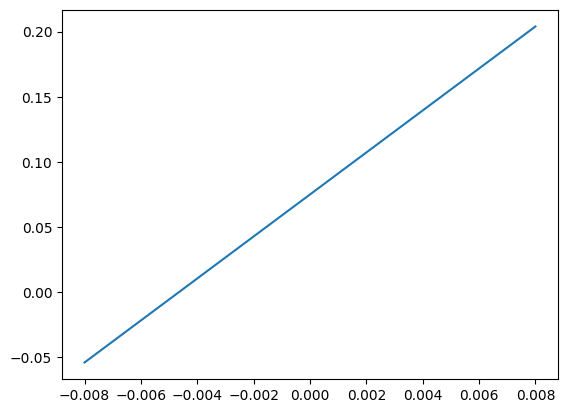

In [1]:
#Importing the libraries
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt

#Forming the a0 r array
mean=[1.04/0.08636,0.96/0.08636]
cov=[[0.29,0],[0,0.18]]
cov=np.array(cov)
num=1000
arr=np.random.multivariate_normal(mean,cov,size=num)

#p**2=t

def f(a0,r,t):
    pcotdelta=1/a0+0.5*r*(t)
    return pcotdelta
    #den=pcosdelta
    #return den

#Forming the bootstrap array
pnum=100
t=np.linspace(-0.008,0.008,pnum)
t=t*(1.704)**2
fparr=[]
for i in range(pnum):
    fp0=[]
    for j in range(num):
       fp0.append(f(arr[j][0],arr[j][1],t[i])) 
    fparr.append(fp0)

#Finding mean and standard deviation
cv=[]
sigma=[]
for i in range(pnum):
    cv.append(fparr[i][0])
    sum=0
    for j in range(num):
        sum+=(fparr[i][j]-cv[i])**2
    sigma.append(np.sqrt(sum/num))

plt.plot(t/(1.704)**2,cv)

Let us plot this with the error-less version of the function.

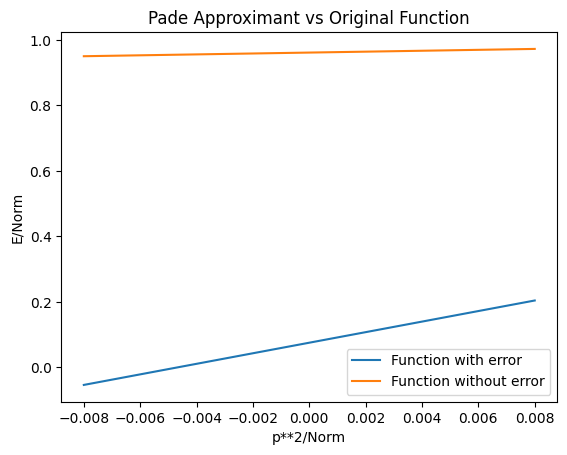

In [2]:
def f0(t):
    a00=1.04
    r0=0.96
    fun=1/a00+0.5*r0*t
    return fun

cv0=[]
for i in range(pnum):
    cv0.append(f0(t[i]))

plt.plot(t/(1.704)**2,cv,label='Function with error')
plt.plot(t/(1.704)**2,cv0,label='Function without error')
plt.legend()
plt.xlabel('p**2/Norm')
plt.ylabel('E/Norm')
plt.title('Pade Approximant vs Original Function')
plt.show()

Now we try to interpolate it with Polynomial fit. First we take a general Polynomial of degree 5 and try minimizing the coefficients. Let us not use Sigma for now.

/usr/local/lib64/python3.12/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/local/lib64/python3.12/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


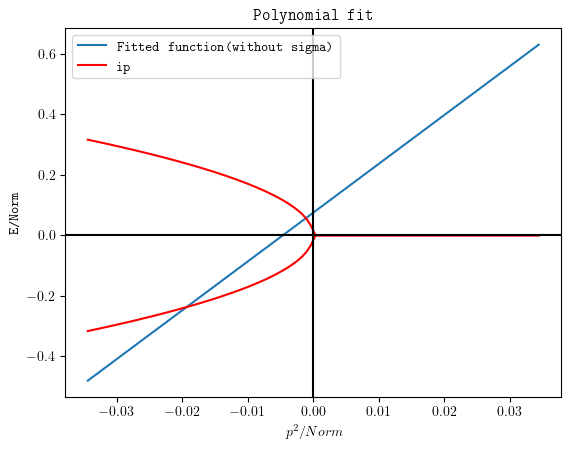

In [3]:
import cmath as cm
cv = np.array(cv)
t = np.array(t)
sigma = np.array(sigma)

coeff=np.polyfit(t,cv,5)
poly=np.poly1d(coeff)

#Finding -ip
def ip(x):
    f=-1j*cm.sqrt(x)
    return f

def mip(x):
    f=1j*cm.sqrt(x)
    return f
    
#Extrapolation from -0.1 to 0.1 with this fit
enum=100
x=np.linspace(-0.1,0.1,enum)

ipval,mipval=[],[]
polyval=poly(x)
[ipval.append(ip(x[i])) for i in range(enum)]
[mipval.append(mip(x[i])) for i in range(enum)]

#plt.plot(t/(1.704)**2,cv,label='Bootstrapped function')
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "monospace",
    "font.monospace": 'Computer Modern Typewriter'
})

plt.plot(x/(1.704)**2,polyval,label='Fitted function(without sigma)')
plt.plot(x/(1.704)**2,ipval,c="red",label='ip')
plt.plot(x/(1.704)**2,mipval,c="red")
plt.legend()
plt.axvline(x=0, c="black", label="x=0")
plt.axhline(y=0, c="black", label="y=0")
plt.xlabel('$p^2/Norm$')
plt.ylabel('E/Norm')
plt.title('Polynomial fit')
plt.show()

Now let us try doing the same, this time, with sigma

/usr/local/lib64/python3.12/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/local/lib64/python3.12/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


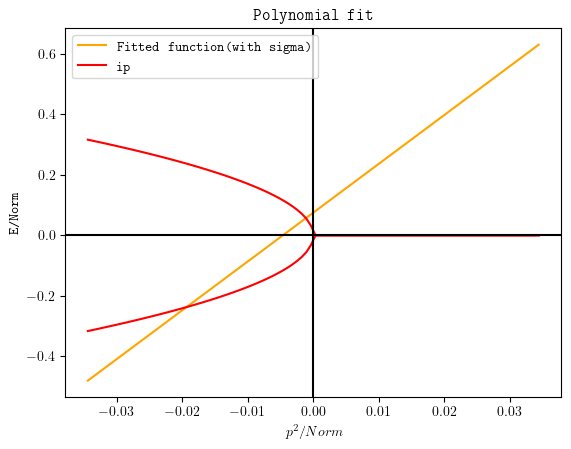

In [4]:
cv = np.array(cv)
t = np.array(t)
sigma = np.array(sigma)

coeff=np.polyfit(t,cv,5,w=1/sigma)
poly2=np.poly1d(coeff)
#Extrapolation from -0.1 to 0.1 with this fit
enum=100
x=np.linspace(-0.1,0.1,enum)

poly2val=poly2(x)

#plt.plot(t/(1.704)**2,cv,label='Bootstrapped function')
"""
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "monospace",
    "font.monospace": 'Computer Modern Typewriter'
})
"""
plt.plot(x/(1.704)**2,poly2val,c="orange",label='Fitted function(with sigma)')
plt.plot(x/(1.704)**2,ipval,c="red",label='ip')
plt.plot(x/(1.704)**2,mipval,c="red")
plt.legend()
plt.axvline(x=0, c="black", label="x=0")
plt.axhline(y=0, c="black", label="y=0")
plt.xlabel('$p^2/Norm$')
plt.ylabel('E/Norm')
plt.title('Polynomial fit')
plt.show()

Now let us add the maximum and minimum value obtained in Bootstrap along with this.

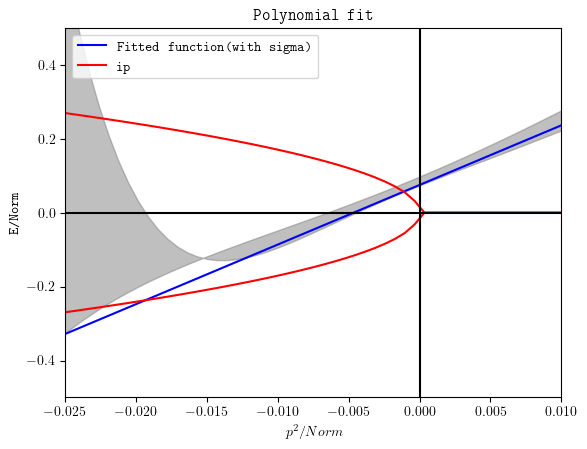

In [5]:
#"""
minarr,maxarr=[],[]
for i in range(pnum):
    minarr.append(np.min(fparr[i]))
    maxarr.append(np.max(fparr[i]))

maxv = np.array(maxarr)
t = np.array(t)
sigma = np.array(sigma)
cmax=np.polyfit(t,maxv,5)
polymax=np.poly1d(cmax)
#Extrapolation from -0.1 to 0.1 with this fit
enum=100
polymaxval=polymax(x)

minv = np.array(minarr)
t = np.array(t)
sigma = np.array(sigma)
cmin=np.polyfit(t,minv,5)
polymin=np.poly1d(cmin)
#Extrapolation from -0.1 to 0.1 with this fit
enum=100
polyminval=polymin(x)

"""
def errorBootstrap(theData, symmetric=False):
     sortSmpls = np.sort(theData[1:], axis=0)
     theData=np.array(theData)
     percentileIndex = int(round((theData.shape[0]-1) * 0.15865525))
     err = (theData[0]-sortSmpls[percentileIndex], 
    sortSmpls[-percentileIndex]-theData[0])
     if symmetric:
       err = 0.5*(err[0] + err[1])
     return err


e0,e1=[],[]
for i in range(pnum):
    max,min=(errorBootstrap(fparr[i]))
    e0.append(min)
    e1.append(max)
"""
plt.plot(x/(1.704)**2,poly2val,c="blue",label='Fitted function(with sigma)')
plt.plot(x/(1.704)**2,ipval,c="red",label='ip')
plt.plot(x/(1.704)**2,mipval,c="red")
plt.fill_between(x/(1.704)**2,polyminval,polymaxval,color='grey', alpha=0.5)
plt.legend()
plt.xlim(-0.025,0.01)
plt.ylim(-0.5,0.5)
plt.axvline(x=0, c="black", label="x=0")
plt.axhline(y=0, c="black", label="y=0")
plt.xlabel('$p^2/Norm$')
plt.ylabel('E/Norm')
plt.title('Polynomial fit')
plt.show()

Let us do the same for the LHCb data (Refer: https://arxiv.org/pdf/2109.01038)

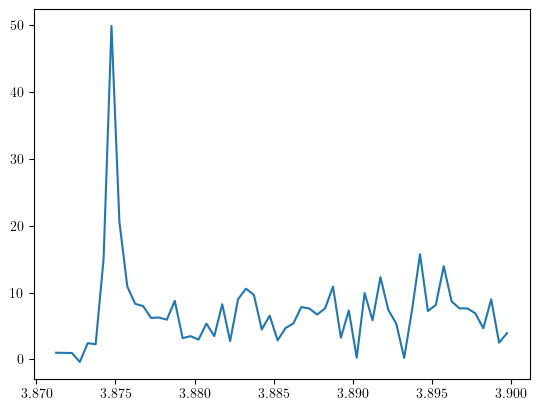

In [6]:
mass=[3.87125,
3.87225,
3.87275,
3.87325,
3.87375,
3.87425,
3.87475,
3.87525,
3.87575,
3.87625,
3.87675,
3.87725,
3.87775,
3.87825,
3.87875,
3.87925,
3.87975,
3.88025,
3.88075,
3.88125,
3.88175,
3.88225,
3.88275,
3.88325,
3.88375,
3.88425,
3.88475,
3.88525,
3.88575,
3.88625,
3.88675,
3.88725,
3.88775,
3.88825,
3.88875,
3.88925,
3.88975,
3.89025,
3.89075,
3.89125,
3.89175,
3.89225,
3.89275,
3.89325,
3.89375,
3.89425,
3.89475,
3.89525,
3.89575,
3.89625,
3.89675,
3.89725,
3.89775,
3.89825,
3.89875,
3.89925,
3.89975,
]

dndm=[0.98259,
0.94201,
-0.39728,
2.416,
2.24996,
14.99021,
49.90962,
20.59526,
10.90579,
8.29965,
7.96751,
6.19034,
6.25549,
5.92648,
8.75937,
3.16666,
3.46311,
2.9465,
5.33952,
3.47564,
8.24576,
2.72161,
8.99575,
10.57157,
9.64679,
4.46762,
6.52827,
2.83937,
4.67296,
5.38269,
7.81879,
7.60814,
6.69582,
7.62466,
10.87914,
3.23346,
7.31497,
0.24026,
9.91521,
5.84158,
12.28863,
7.37776,
5.3366,
0.20278,
7.42926,
15.72794,
7.21916,
8.14348,
13.93615,
8.65875,
7.62622,
7.61831,
6.87976,
4.63632,
8.98105,
2.4861,
3.92134,
]

sigma1=[0.98259,
0.94201,
0.39728,
1.61382,
1.59134,
4.07927,
7.50035,
4.99569,
3.55721,
3.03986,
2.97109,
2.75919,
2.64061,
3.22836,
2.9074,
1.92388,
2.65775,
2.275,
2.65419,
2.83567,
3.35008,
2.03089,
3.06818,
3.4877,
3.44558,
2.75155,
3.14364,
2.36384,
2.70638,
2.79798,
3.07708,
2.90429,
2.91918,
3.13844,
3.46545,
2.61822,
3.14126,
2.80507,
3.64031,
2.71579,
4.39106,
3.07348,
3.0931,
2.96833,
3.5556,
4.29047,
3.46244,
3.47513,
4.34802,
3.33768,
3.10434,
3.13799,
3.57329,
3.23274,
3.67436,
3.10612,
2.64661,
]

plt.plot(mass,dndm)

/tmp/ipykernel_8487/2766792973.py:5: RankWarning: Polyfit may be poorly conditioned
  coeff=np.polyfit(mass,dndm,6,w=1/sigma)


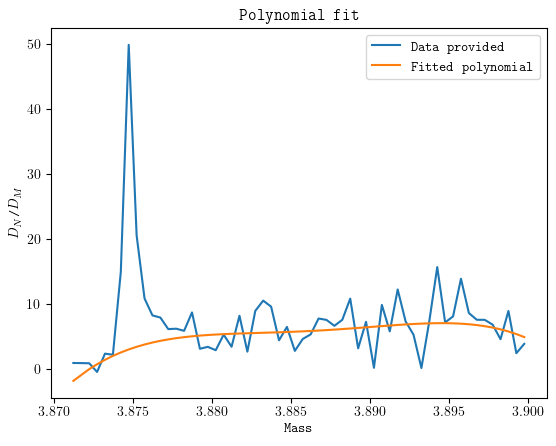

In [7]:
dndm = np.array(dndm)
mass = np.array(mass)
sigma = np.array(sigma1)

coeff=np.polyfit(mass,dndm,6,w=1/sigma)
polyc=np.poly1d(coeff)
polycval=polyc(mass)
#Extrapolation from -0.1 to 0.1 with this fit
#enum=100
#x=np.linspace(-0.1,0.1,enum)

plt.plot(mass,dndm,label="Data provided")
plt.plot(mass,polycval,label="Fitted polynomial")
plt.legend()
plt.xlabel('Mass')
plt.ylabel('$D_N$/$D_M$')
plt.title('Polynomial fit')
plt.show()

So this is not a perfect fit. So we need to try some other fit for this data. The paper uses the Breit-Wigner
distribution. So let us use that.

[0.04240819 3.89217054 0.01913505]


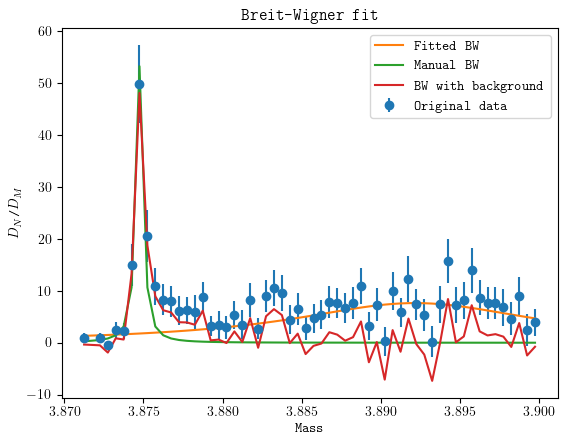

In [8]:
from scipy.optimize import curve_fit
dndm = np.array(dndm)
mass = np.array(mass)
sigma = np.array(sigma)

def bwd(x,k,m,g):
    #k=par[0]
    #m=par[1]
    #g=par[2]
    fun=k/(((x**2)-(m**2))**2+(m**2)*(g**2))
    return fun

p0=[0,3.8,0]
par,pcov=curve_fit(bwd,mass,dndm,sigma=sigma)
print(par)
func1=bwd(mass,par[0],par[1],par[2])

#Manually doing the Breit Wigner fit
func2=bwd(mass,0.0002,3.87475,0.0005)
func3=dndm-func1

plt.errorbar(mass, dndm, yerr=sigma, fmt='o', label='Original data')
plt.plot(mass,func1,label="Fitted BW ")
plt.plot(mass,func2,label="Manual BW ")
plt.plot(mass,func3,label="BW with background")
plt.legend()
plt.xlabel('Mass')
plt.ylabel('$D_N$/$D_M$')
plt.title('Breit-Wigner fit')
plt.show()

The Breit Wigner curve fit is fitting wrongly because of the noise in the end, which kind of skews the fit towards
it. This can be done by setting the maxima point near the maxima of data points and then trying to fit the data, or delete the 
background noise somehow. Now, let us move to real Pade approximation.

Roots [-1.93249727+0.j         -1.40442787+1.30002602j -1.40442787-1.30002602j
 -0.22740997+1.77011587j -0.22740997-1.77011587j  1.06440109+1.35696255j
  1.06440109-1.35696255j  1.28002954+0.j          0.80129222+0.j
 -0.01395098+0.j        ]
Poles [-5.73241736+0.j         -0.26507394+5.51562625j -0.26507394-5.51562625j
  5.18038537+0.j         -0.51021405+0.j         -0.20513862+0.45742149j
 -0.20513862-0.45742149j  0.28975071+0.36487032j  0.28975071-0.36487032j
  0.42316974+0.j        ]


/home/bathri/.local/lib/python3.12/site-packages/scipy/optimize/_minpack_py.py:1010: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',
/usr/local/lib64/python3.12/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/local/lib64/python3.12/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


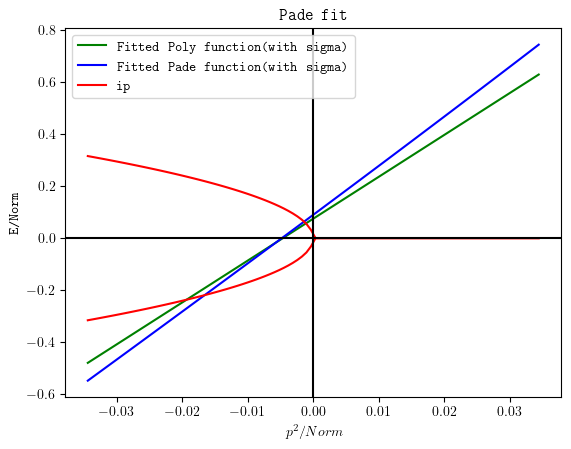

In [9]:
#Forming the a0 r array
mean=[1.04/0.08636,0.96/0.08636]
cov=[[0.29,0],[0,0.18]]
cov=np.array(cov)
num=1000
arr=np.random.multivariate_normal(mean,cov,size=num)

#p**2=t

def f(a0,r,t):
    pcotdelta=1/a0+0.5*r*(t)
    return pcotdelta
    #den=pcosdelta
    #return den

#Forming the bootstrap array
pnum=100
t=np.linspace(-0.008,0.008,pnum)
t=t*(1.704)**2
fparr=[]
for i in range(pnum):
    fp0=[]
    for j in range(num):
       fp0.append(f(arr[j][0],arr[j][1],t[i])) 
    fparr.append(fp0)

#Finding mean and standard deviation
cv=[]
sigma=[]
for i in range(pnum):
    cv.append(fparr[i][0])
    sum=0
    for j in range(num):
        sum+=(fparr[i][j]-cv[i])**2
    sigma.append(np.sqrt(sum/num))
    
# Real Pade approximation
def real_pade(t, cv, sigma, m, n):
    def pade(x, *coeff):
        numc = coeff[:m+1]
        denc = coeff[m+1:]
        num = np.polyval(numc[::-1], x)
        den = 1 + np.polyval(denc[::-1], x)
        return num / den

    initial_guess = np.ones(m + n + 1)
    par, pcov = curve_fit(pade, t, cv, sigma=sigma, p0=initial_guess)

    numco = par[:m+1]
    numpoly = np.poly1d(numco[::-1])
    denco = par[m+1:]
    denpoly = np.poly1d(np.concatenate(([1.0], denco[::-1])))
    c=denpoly(0)
    numpoly=numpoly/c
    denpoly=denpoly/c
    
    return numpoly, denpoly

# Define degrees m and n
m = 10
n = 10

# Calculate the Pade approximant
npoly, dpoly = real_pade(t, cv, sigma, m, n)
print("Roots", np.roots(npoly))
print("Poles", np.roots(dpoly))

# Calculate Pade approximant values
pade_approx_values = npoly(t) / dpoly(t)

# Extrapolation from -0.1 to 0.1 with this fit
x = np.linspace(-0.1, 0.1, 100)
pval = npoly(x) / dpoly(x)

# Plot the results
plt.plot(x/(1.704)**2,poly2val,c="green",label='Fitted Poly function(with sigma)')
plt.plot(x/(1.704)**2,pval,c="blue",label='Fitted Pade function(with sigma)')
plt.plot(x/(1.704)**2,ipval,c="red",label='ip')
plt.plot(x/(1.704)**2,mipval,c="red")
plt.legend()
plt.axvline(x=0, c="black", label="x=0")
plt.axhline(y=0, c="black", label="y=0")
plt.xlabel('$p^2/Norm$')
plt.ylabel('E/Norm')
plt.title('Pade fit')
plt.show()

array([-3.44863617,  1.95922066])

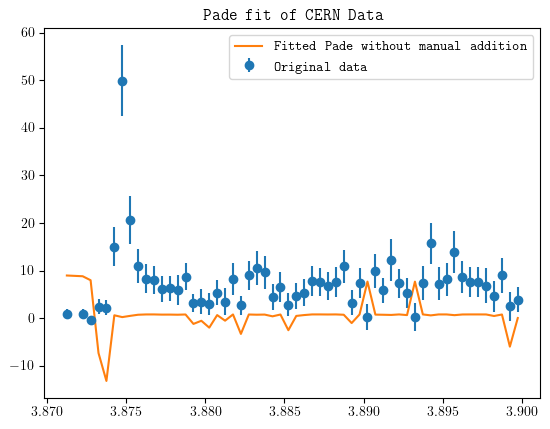

In [10]:
dndm = np.array(dndm)
mass = np.array(mass)
sigma = np.array(sigma1)

npoly,dpoly=real_pade(mass,dndm,sigma,1,2)
pvalue=npoly(dndm)/dpoly(dndm)
plt.errorbar(mass, dndm, yerr=sigma, fmt='o', label='Original data')
plt.plot(mass,pvalue,label="Fitted Pade without manual addition")
plt.legend()
plt.title('Pade fit of CERN Data')
dpoly.r

It does well with the generated data, but fails with CERN data. So let us try artificial addition of poles

[3.872601682607949, 3.872820607973611] [3.87475, 3.87775, 3.87975, 3.88325, 3.89575]


Text(0.5, 1.0, 'Pade fit of CERN Data')

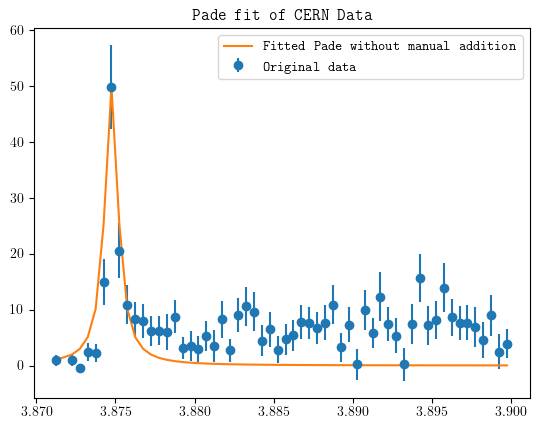

In [11]:
def real_scanner(x, y):
    root, pole = [], []
    # Finding the roots of the polynomial
    for i in range(len(y) - 1):
        if y[i] * y[i + 1] <= 0:
            root_x = x[i] - y[i] * (x[i + 1] - x[i]) / (y[i + 1] - y[i])
            root.append(root_x)
            
    # Finding the poles of the function
    dx = x[1] - x[0]
    dydx = np.gradient(y, dx)
    
    for i in range(len(dydx) - 1):
        if dydx[i + 1] / dydx[i] <= -5:  # Change the threshold as needed
            pole.append(x[i])
    return root, pole

root, pole = real_scanner(mass,dndm)
print(root,pole)
i=np.argmax(dndm)
max=mass[i]
dx=x[1]-x[0]
k=dndm[i]*((dx/2)**2)*((mass[i])**2)
bwm=bwd(mass,k,pole[0],dx/2)
plt.errorbar(mass, dndm, yerr=sigma, fmt='o', label='Original data')
plt.plot(mass,bwm,label="Fitted Pade without manual addition")
plt.legend()
plt.title('Pade fit of CERN Data')

So this does work. Now let us do the reverse of what we did initially with the Breit Wigner. Let us reduce the 
background noise and try doing bwd or Pade routines we developed.

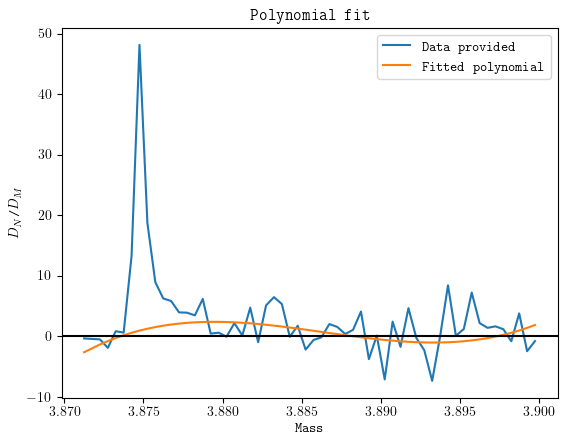

In [17]:
coeff=np.polyfit(mass,func3,3,w=1/sigma)
polyc=np.poly1d(coeff)
polycval=polyc(mass)
#Extrapolation from -0.1 to 0.1 with this fit
#enum=100
#x=np.linspace(-0.1,0.1,enum)

plt.plot(mass,func3,label="Data provided")
plt.plot(mass,polycval,label="Fitted polynomial")
plt.legend()
plt.axhline(y=0, c="black", label="y=0")
plt.xlabel('Mass')
plt.ylabel('$D_N$/$D_M$')
plt.title('Polynomial fit')
plt.show()

[  53.6836002   142.68341971 9270.4678841 ]


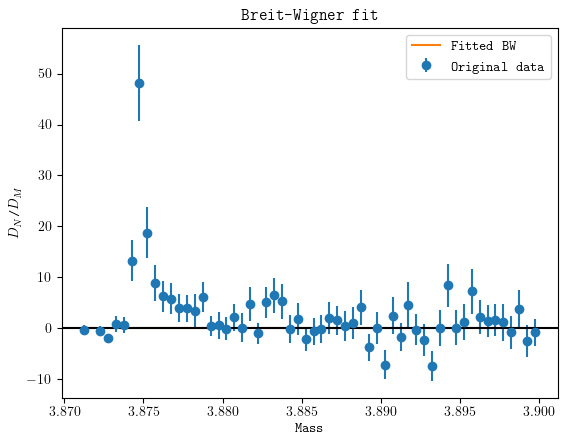

In [20]:
p0=[0,3.8,0]
par,pcov=curve_fit(bwd,mass,func3,sigma=sigma1)
print(par)
func1=bwd(mass,par[0],par[1],par[2])

plt.errorbar(mass, func3, yerr=sigma, fmt='o', label='Original data')
plt.plot(mass,func1,label="Fitted BW ")
plt.legend()
plt.xlabel('Mass')
plt.ylabel('$D_N$/$D_M$')
plt.title('Breit-Wigner fit')
plt.axhline(y=0, c="black", label="y=0")
plt.show()

array([-4.73778919,  2.24574977])

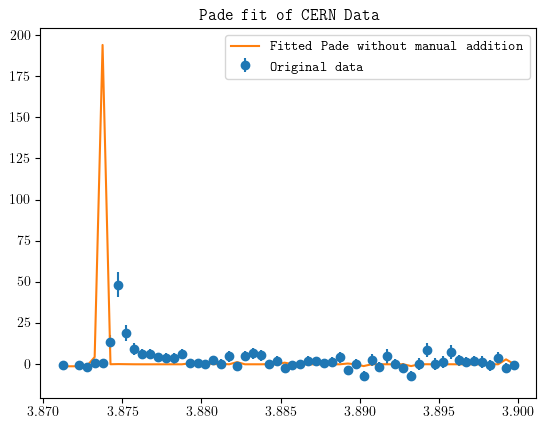

In [29]:
npoly,dpoly=real_pade(mass,func3,sigma,1,2)
pvalue=-npoly(dndm)/dpoly(dndm)
plt.errorbar(mass, func3, yerr=sigma, fmt='o', label='Original data')
plt.plot(mass,pvalue,label="Fitted Pade without manual addition")
plt.legend()
plt.title('Pade fit of CERN Data')
dpoly.r

This ends the Bootstrap sampling and analysis using Pade functions. Other methods will be included in the next
notebook

-Bathri